# 02 - Exploratory Data Analysis

## Project
Telecom Customer Retention Intelligence Platform

### Purpose
The purpose of this notebook is to explore relationships between customer attributes and churn behavior through visual and statistical analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("../data/raw/Telco_customer_churn.xlsx")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.shape

(7043, 33)

# 1. Payment Method vs Churn

### Analysis Objective

The objective of this analysis is to investigate whether different payment methods are associated with customer churn. Understanding this relationship may help identify customer payment behaviors linked to higher churn risk.

In [4]:
pd.crosstab(
    df["Payment Method"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


### Observation

Customers using **Electronic check** exhibit the highest churn rate (**45.29%**), while customers using **automatic payment methods** (bank transfer or credit card) have significantly lower churn rates.

### Business Insight

Encouraging customers to adopt automatic payment methods may help reduce customer churn. Promotional campaigns or incentives for automatic payments could improve customer retention.

### Machine Learning Perspective

The **Payment Method** feature demonstrates a meaningful relationship with customer churn and should be included as an important categorical variable in the churn prediction model.

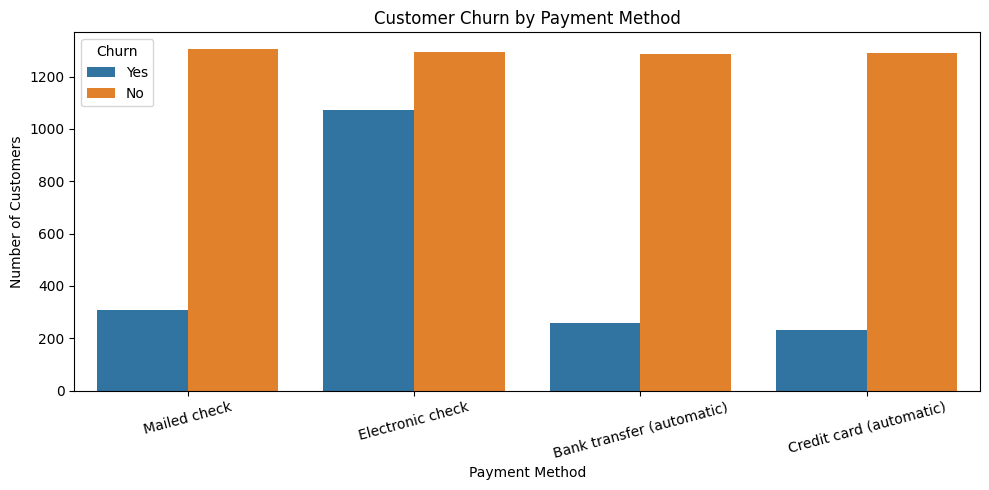

In [5]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Payment Method",
    hue="Churn Label"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

# 2. Monthly Charges vs Churn

### Analysis Objective

The objective of this analysis is to investigate whether customers with higher monthly charges are more likely to churn. Understanding this relationship can help evaluate the impact of pricing on customer retention.

In [7]:
df.groupby("Churn Label")["Monthly Charges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


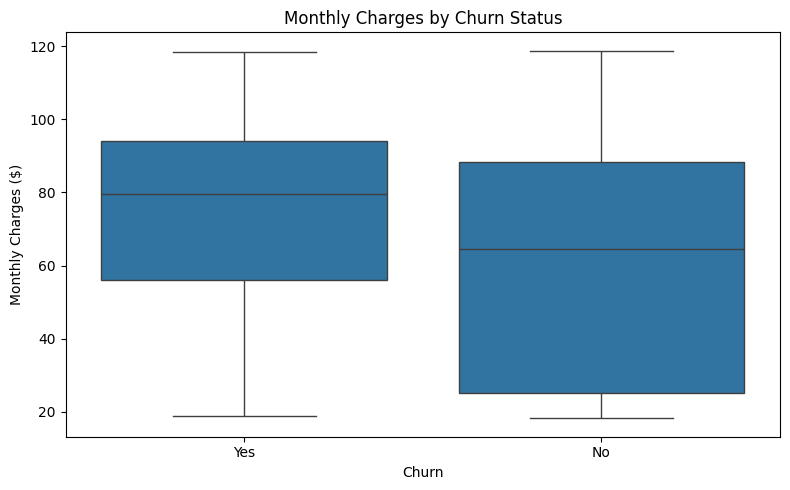

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges ($)")

plt.tight_layout()
plt.show()

### Observation

Customers who churned tend to have higher monthly charges than customers who remained with the company. Both the average and median monthly charges are noticeably higher for churned customers.

### Business Insight

Higher monthly charges are associated with higher customer churn. The company should evaluate whether pricing, perceived value, or service quality influences customer decisions, especially among customers with premium plans.

### Machine Learning Perspective

The **Monthly Charges** feature demonstrates a meaningful relationship with customer churn and is expected to be an important numerical predictor in the churn prediction model.

# 3. Correlation Analysis

### Analysis Objective

The objective of this analysis is to examine the relationships between numerical variables in the dataset. Correlation analysis helps identify features that are strongly associated with customer churn and reveals potential relationships among numerical variables before model development.

In [9]:
df.select_dtypes(include=["int64", "float64"]).columns

Index(['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months',
       'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV'],
      dtype='object')

In [10]:
numeric_df = df[
    [
        "Tenure Months",
        "Monthly Charges",
        "Churn Value"
    ]
]

numeric_df.corr()

,Tenure Months,Monthly Charges,Churn Value
Tenure Months,1.000000,0.247900,-0.352229
Monthly Charges,0.247900,1.000000,0.193356
Churn Value,-0.352229,0.193356,1.000000


### Observation

The correlation matrix shows that **Tenure Months** has a moderate negative correlation with churn (-0.35), indicating that customers with longer tenure are less likely to leave the company. **Monthly Charges** has a weak positive correlation (0.19), suggesting that customers paying higher monthly fees tend to churn slightly more often.

### Business Insight

The company should prioritize retaining customers during their early months and closely monitor customers with higher monthly charges. Although pricing alone does not explain churn, it may contribute when combined with other factors.

### Machine Learning Perspective

Correlation analysis confirms that **Tenure Months** is one of the strongest numerical predictors of churn in the dataset. However, additional categorical features such as **Contract** and **Internet Service** are also expected to play a significant role during model training.

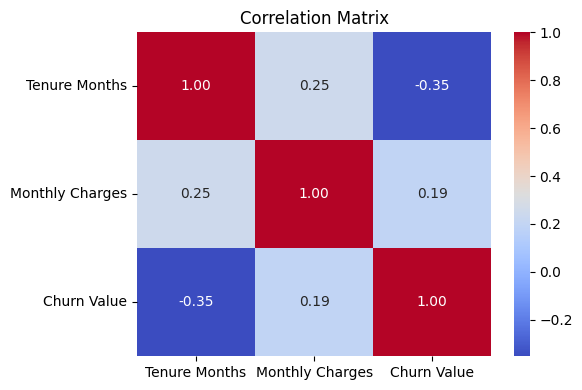

In [11]:
plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

### Observation

The heatmap confirms that **Tenure Months** has the strongest numerical relationship with customer churn among the selected variables. Customers with longer tenure are less likely to churn, while **Monthly Charges** shows only a weak positive relationship with churn.

### Business Insight

Customer retention strategies should primarily focus on increasing customer longevity. Pricing alone is unlikely to explain churn; therefore, pricing strategies should be evaluated together with contract types, internet services, and customer satisfaction.

### Machine Learning Perspective

The correlation analysis validates previous findings from the exploratory analysis. **Tenure Months** is expected to be one of the most influential numerical features, while **Monthly Charges** may become more informative when combined with categorical variables during model training.